In [1]:
# 7-16-2026

In [2]:
# i made an embedding pca colored by pyrome
# i want to do this specifically with the fire branch embeddings, since fire branch embedding dist correlated 
#   with pyrome compositions much more than the other branches.

In [3]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [4]:
embeddings = pd.read_csv("domain_embeddings_v4.csv")
vectors = pd.read_csv("../data/domain_pyrome_vectors.csv")
pyrome_cols = [c for c in vectors.columns if c.startswith("pyrome_")]

In [5]:
vectors.head()

,domain,total_cells,covered_cells,coverage_pct,pyrome_1_pct,pyrome_2_pct,pyrome_3_pct,pyrome_4_pct,pyrome_5_pct
0,0,13812,11932,0.8639,0.0725,0.5493,0.1311,0.1057,0.1415
1,1,6356,2132,0.3354,0.0023,0.5417,0.3583,0.0441,0.0535
2,2,7325,5065,0.6915,0.5088,0.0486,0.0689,0.3641,0.0097
3,4,51331,17421,0.3394,0.0289,0.1765,0.3515,0.4106,0.0325
4,5,5788,4886,0.8442,0.0098,0.5813,0.2075,0.0718,0.1296


In [6]:
full_merged = embeddings.merge(vectors, left_on="domain_id", right_on="domain", how="inner")
# only fire branch dims (e_6, e_7, e_8)
fire_cols = [c for c in embeddings.columns if c.startswith("e_")][6:9]
X_fire = full_merged[fire_cols].values

In [7]:
pca_fire = PCA(n_components=2)
X_fire_pca = pca_fire.fit_transform(X_fire)
print("explained variance ratio:", pca_fire.explained_variance_ratio_)

explained variance ratio: [0.45717912 0.43812421]


In [8]:
full_merged["dominant_pyrome"] = full_merged[pyrome_cols].idxmax(axis=1)
cat_codes = full_merged["dominant_pyrome"].astype("category")
point_colors = [plt.cm.tab10.colors[i] for i in cat_codes.cat.codes]

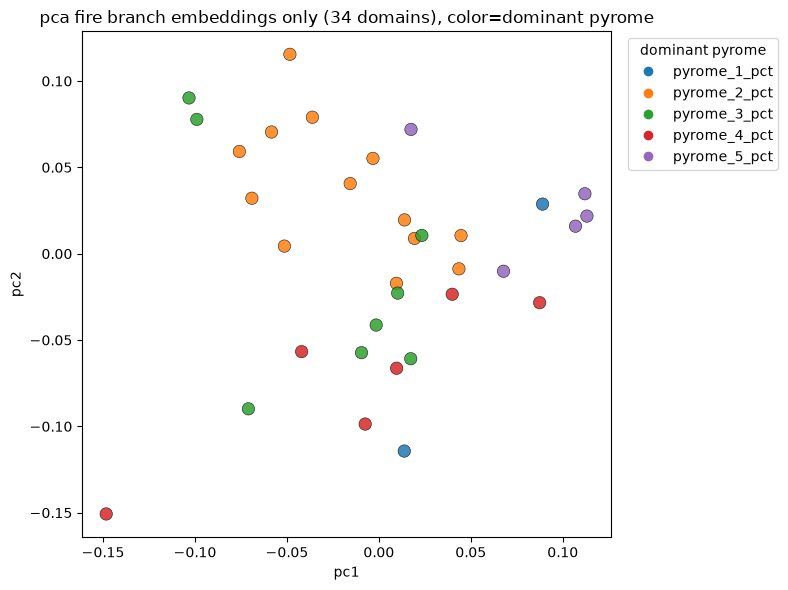

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_fire_pca[:, 0],
    X_fire_pca[:, 1],
    c=point_colors,
    alpha=0.85,
    s=80,
    edgecolor="black",
    linewidth=0.4,
)
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=plt.cm.tab10.colors[i])
    for i in range(len(cat_codes.cat.categories))
]
plt.legend(handles, cat_codes.cat.categories.tolist(), title="dominant pyrome", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xlabel("pc1")
plt.ylabel("pc2")
plt.title("pca fire branch embeddings only (34 domains), color=dominant pyrome")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.neighbors import NearestNeighbors

k = 3
nn = NearestNeighbors(n_neighbors=k+1).fit(X_fire_pca)
_, idx = nn.kneighbors(X_fire_pca)

labels = cat_codes.cat.codes.values
agree = np.mean([
    np.mean(labels[idx[i, 1:]] == labels[i])
    for i in range(len(labels))
])
print(f"mean fraction of {k} nearest neighbors w same label: {agree:.4f}")

# frac of x means for any given point, an average of x*3 points share the same label

mean fraction of 3 nearest neighbors w same label: 0.4804


In [ ]:
n_perms = 1000
rng = np.random.default_rng(0)
perm_scores = []

for _ in range(n_perms):
    shuffled = rng.permutation(labels)
    score = np.mean([
        np.mean(shuffled[idx[i, 1:]] == shuffled[i])
        for i in range(len(shuffled))
    ])
    perm_scores.append(score)

perm_scores = np.array(perm_scores)
print(f"baseline mean: {perm_scores.mean():.4f}, std: {perm_scores.std():.4f}")
print(f"z-scored frac nearest neighbor: {(agree - perm_scores.mean()) / perm_scores.std():.2f}")

# the class imbalance in colors/zones/pyromes/classes in the pca could artifically bring up the frac, so 
#   shuffle the labels around (keep the points fixed, just randomly reasign which point gets which label), 
#   and recompute the same nearest-neighbor score, do that 1000 times and avg/std to get baseline
# basically, what to expect from pure chance given class sizes

baseline mean: 0.2357, std: 0.0516
z-scored frac nearest neighbor: 4.74


In [12]:
from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr

In [13]:
pyrome_matrix = full_merged[pyrome_cols].values

n = len(full_merged)
js_dist_grid = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        js_dist_grid[i, j] = jensenshannon(pyrome_matrix[i], pyrome_matrix[j])

# fire embedding sq dist, all pairs
diff = X_fire[:, None, :] - X_fire[None, :, :]
fire_sq_grid = (diff ** 2).sum(axis=-1)

In [ ]:
off_diag_mask = ~np.eye(n, dtype=bool)
js_dist_od = js_dist_grid[off_diag_mask]
fire_dist_od = fire_sq_grid[off_diag_mask]

corr, p = spearmanr(fire_dist_od, js_dist_od)
print(f"fire branch sq dist vs pyrome js divergence, off-diag spearman: {corr:.4f}") # good same as last time

fire branch sq dist vs pyrome js divergence, off-diag spearman: 0.5006


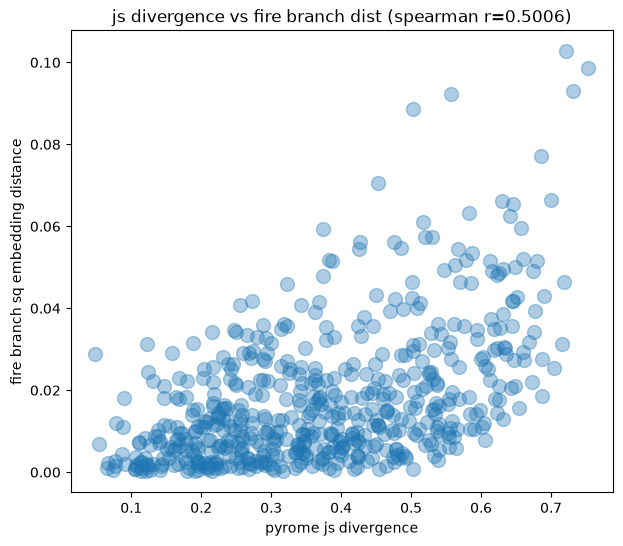

In [23]:
plt.figure(figsize=(7, 6))
plt.scatter(js_dist_od, fire_dist_od, alpha=0.2, s=100)
plt.xlabel("pyrome js divergence")
plt.ylabel("fire branch sq embedding distance")
plt.title(f"js divergence vs fire branch dist (spearman r={corr:.4f})")
plt.show()